In [ ]:
%%capture
!pip install networkx
!pip install yfinance
!pip install fredapi

In [ ]:
import networkx as nx
import yfinance as yf
from fredapi import Fred as fd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np
from scipy.stats import norm

In [ ]:
fred = fd(api_key='Useurkey')

# Step 5: Money Lending Scenario



> We'll first see how commercial banks are spending on their loans and lending activities



In [ ]:
real_estate_loan = fred.get_series('CREACBW027SBOG', observation_start='2004-06-02', observation_end='2024-10-09')
consumer_loan = fred.get_series('CLSACBW027SBOG', observation_start='2004-06-02', observation_end='2024-10-09')

Text(0.5, 1.0, 'Real Estate and Consumer Loans')

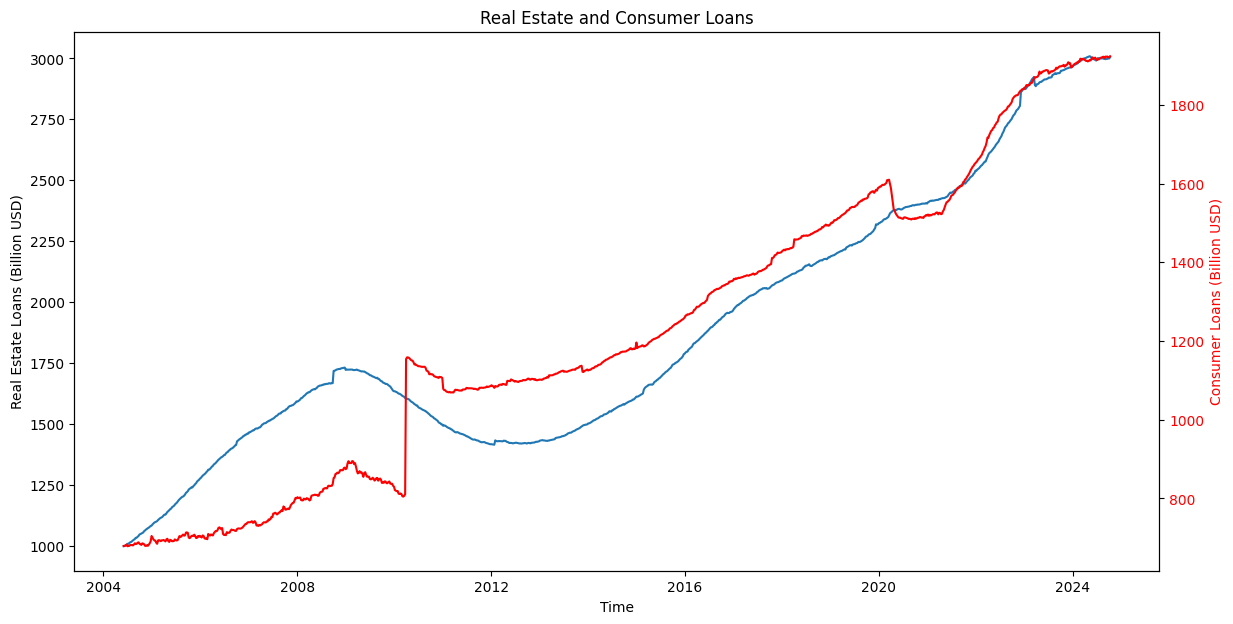

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(14, 7)
ax.plot(real_estate_loan.index, real_estate_loan.values, label='Real Estate Loans')
ax.set_xlabel('Time')
ax.set_ylabel('Real Estate Loans (Billion USD)')

ax2 = ax.twinx()
ax2.plot(consumer_loan.index, consumer_loan.values, color='r', label='Consumer Loans')
ax2.set_ylabel('Consumer Loans (Billion USD)', color='r')
ax2.tick_params(axis='y', labelcolor='r')

ax.set_title('Real Estate and Consumer Loans')



> We can observe a clear growing loan and lending activities of commercial banks in both real estate and consumer loans

> After the Financial Crisis in 2008 and the recession in 2020 due to COVID, lending activities witnessed a fall but quickly rebounded soon after that.




> Banks will pay attention to credit risk and default rate of their borrowrers.

> So let's look for banks' non-performing loans (in which payments of interest and principal past due by 90 days or more). First in the US




In [ ]:
non_performing_loan_ratio = fred.get_series('DDSI02USA156NWDB', observation_start='1998-01-01', observation_end='2020-01-01')

Text(0.5, 1.0, 'Bank non-performing loans to gross loans, United States')

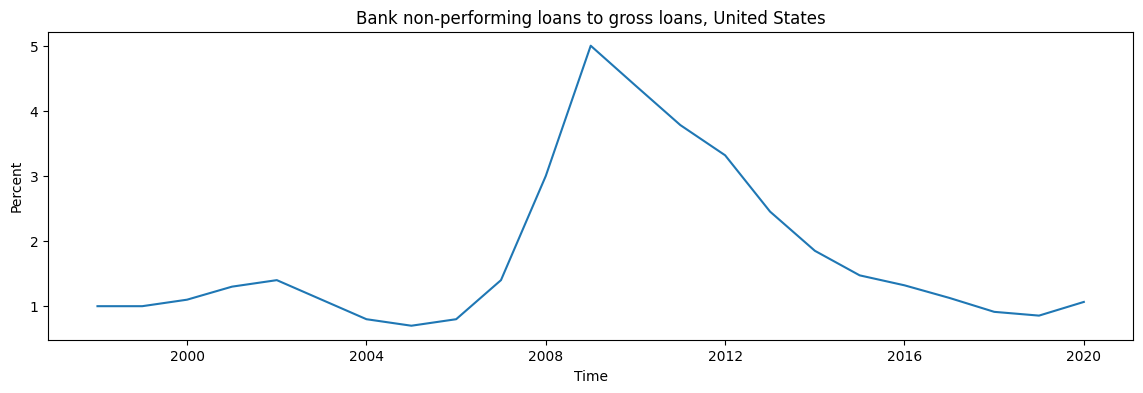

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(14, 4)
ax.plot(non_performing_loan_ratio.index, non_performing_loan_ratio.values)
ax.set_xlabel('Time')
ax.set_ylabel('Percent')
ax.set_title('Bank non-performing loans to gross loans, United States')

> The ratio of non-performing loan to gross loans is well under 3%, except for the period after the GFC

> Let's get data from other countries and plot other graphs to further analyze this statistic

In [ ]:
all_loans_ratio_series = fred.search('Bank Non-Performing Loans to Gross Loans')

In [ ]:
all_loans_ratio = {'US': non_performing_loan_ratio.to_dict()}
for idx, row in all_loans_ratio_series[1:].iterrows():
    data = fred.get_series(row['id'], observation_start='1998-01-01', observation_end='2020-01-01')
    country = row['title'].replace('Bank Non-Performing Loans to Gross Loans for ', '')
    all_loans_ratio[country] = data.to_dict()

In [ ]:
all_loans_ratio_df = pd.DataFrame(all_loans_ratio)

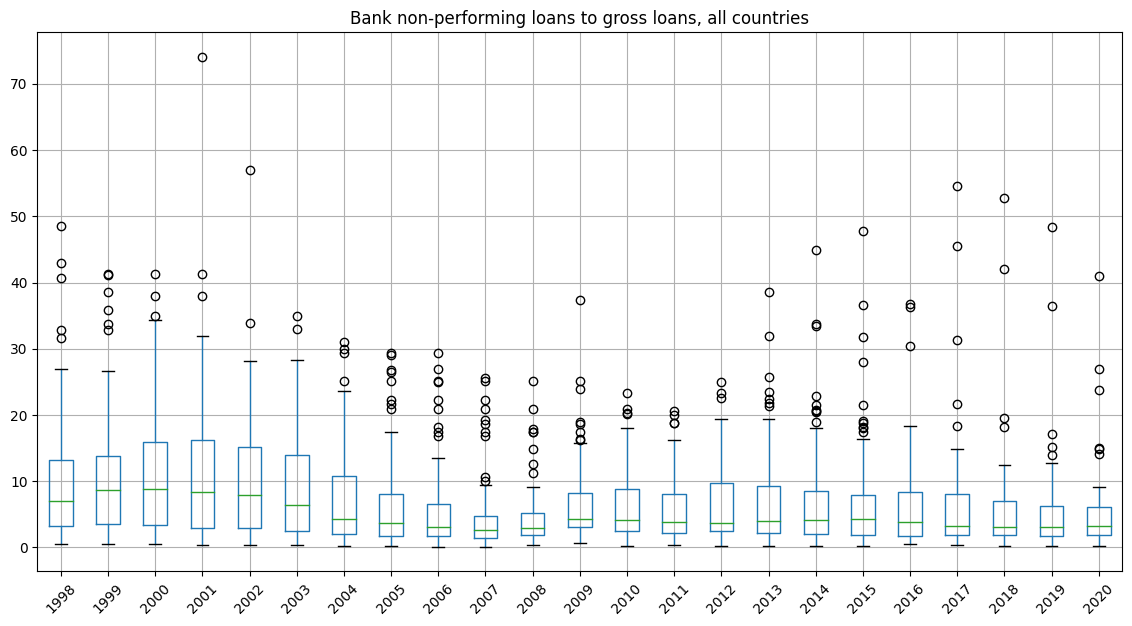

In [ ]:
df_transposed = all_loans_ratio_df.T

fig, ax = plt.subplots()
fig.set_size_inches(14, 7)

df_transposed.boxplot(ax=ax)
ax.set_xticklabels(all_loans_ratio_df.index.year, rotation=45)
ax.set_title('Bank non-performing loans to gross loans, all countries')
plt.show()

> We can see that the median of non-performing loans ratio in all countries is under 10%, and the majority are under 20%. There are few countries with high ratio (30% - 50%, and up to 70%) which are considered as outliers. The minimum ratio can go as low as 1 - 2%

> We can assume that it is safe and profitable for banks in commercial lending activities

> We should have different lending policies for countries with low non-performing loans ratio and ones with high ratio. Looking at the data, we can see that more developed countries have lower default ratio

> There are many factors which affect the default rate in developing countries, so let's further investigate countries with more stable and lower ratio to see if we can find any pattern.

In [ ]:
# Filter for countries with non-performing loans ratio always less than 10%
low_loans_ratio = all_loans_ratio_df.loc[:, (all_loans_ratio_df < 10).all()]

Text(0.5, 1.0, 'Bank Non-Performing Loans to Gross Loans, countries with ratio < 10%')

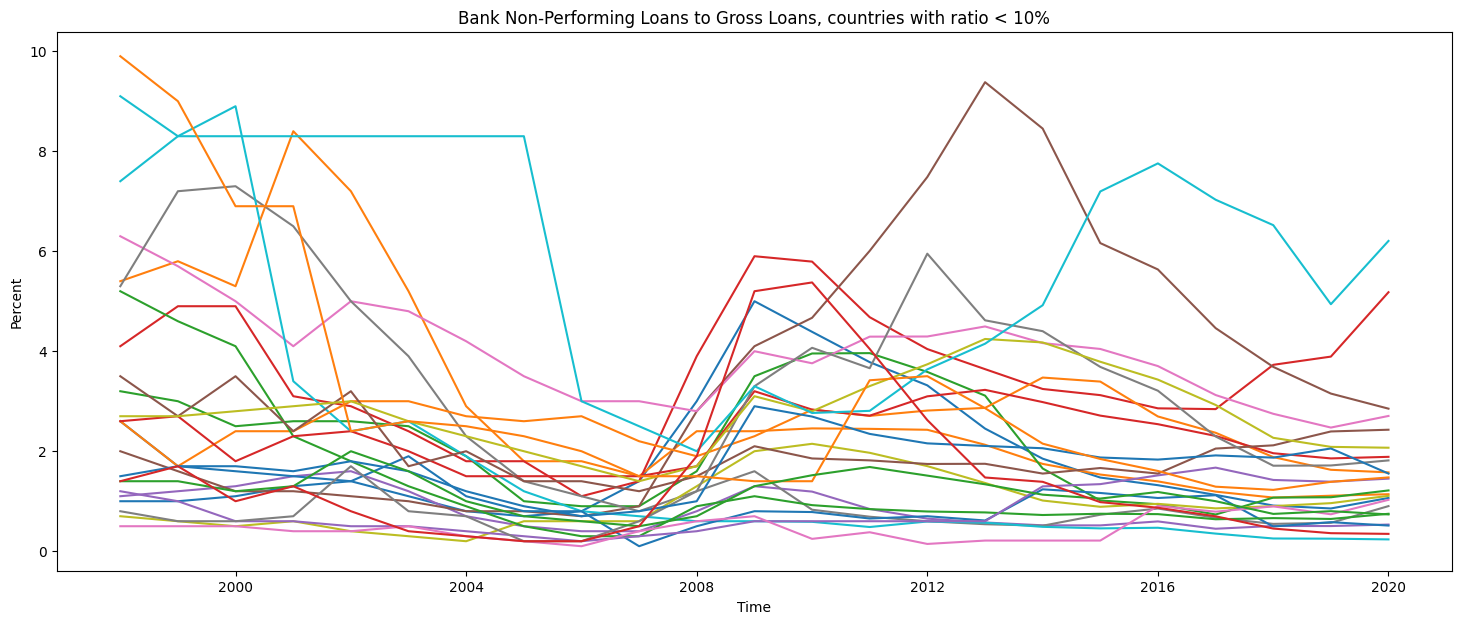

In [ ]:
fig, ax = plt.subplots()
fig.set_size_inches(18, 7)
for col_name in low_loans_ratio.columns.values:
    ax.plot(low_loans_ratio.index, low_loans_ratio[col_name])
ax.set_xlabel('Time')
ax.set_ylabel('Percent')
ax.set_title('Bank Non-Performing Loans to Gross Loans, countries with ratio < 10%')



> It can be seen that GFC has a significant impact in these countries. So banks in developed economies should be cautious with lending activities during the time of recession



# Step 6: Security Lending Scenario

In [ ]:
ticker='AAPL'
df=yf.download(ticker,period='5y',interval='1d') #importing equity data for the past 5years

[*********************100%***********************]  1 of 1 completed


In [ ]:
#Volatility estimate using ewma
#using bootstrap techniques to estimate the VaR  (distribution independent)

In [ ]:
#We start by preprocessing
df['log_price']=np.log(df['Close'])
df['ret']=df['Close'].pct_change()
y=0.80 #can be changed
df['ewma_vol']=df['ret'].pow(2).ewm(alpha=1-y,adjust=False).mean().pow(0.5) #using the EWMA model to estimate the volatility
#this is an implementation of week 6
df['volume_20dma'] = df['Volume'].rolling(window=20).mean() #smoothing on the monthly


df=df.dropna()


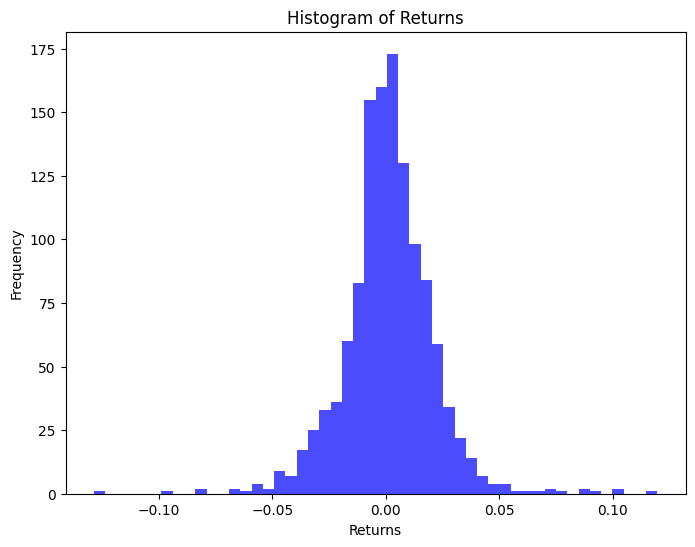

In [ ]:
#visualization of returns, log prices, volume and volatilty
plt.figure(figsize=(8, 6))
plt.hist(df['ret'], bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Returns')
plt.xlabel('Returns')
plt.ylabel('Frequency')
plt.show()


We show how returns are distributed using the returns of the past 5 years on a daily scale

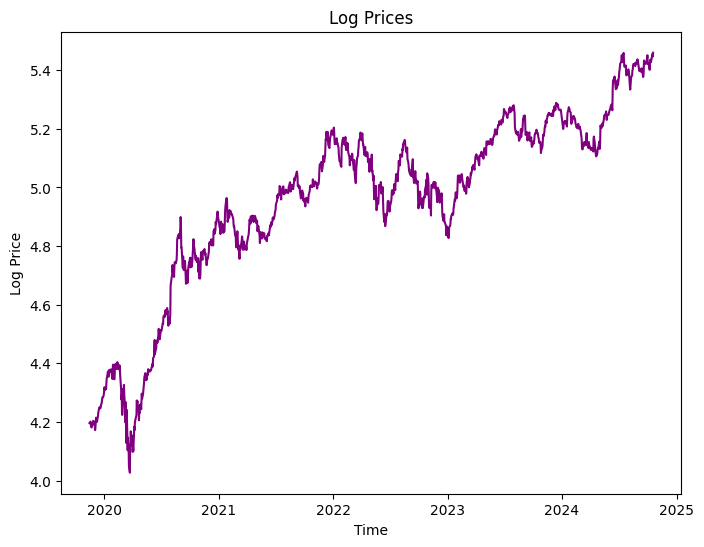

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(df['log_price'], color='purple')
plt.title('Log Prices')
plt.xlabel('Time')
plt.ylabel('Log Price')
plt.show()

the log price of AAPL for the past 5 years.

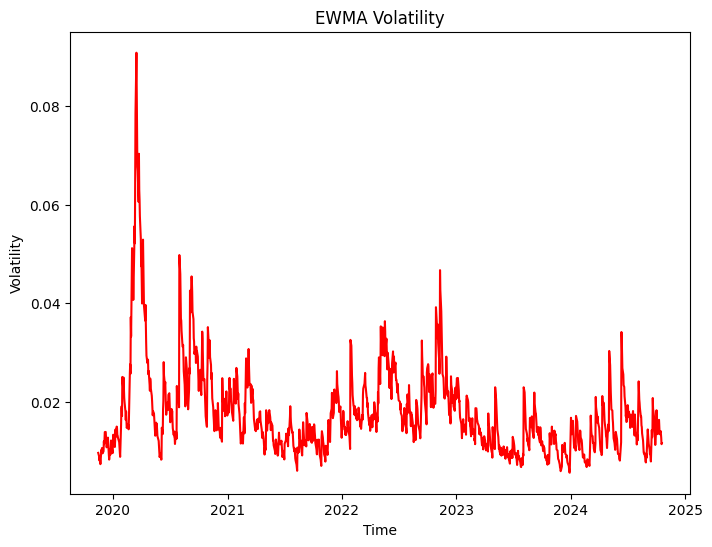

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(df['ewma_vol'], color='red')
plt.title('EWMA Volatility')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.show()

The volatility as a measure of risk in the past 5 years, we see the pandamic effect in 2020 and the crash of septemper in 2022

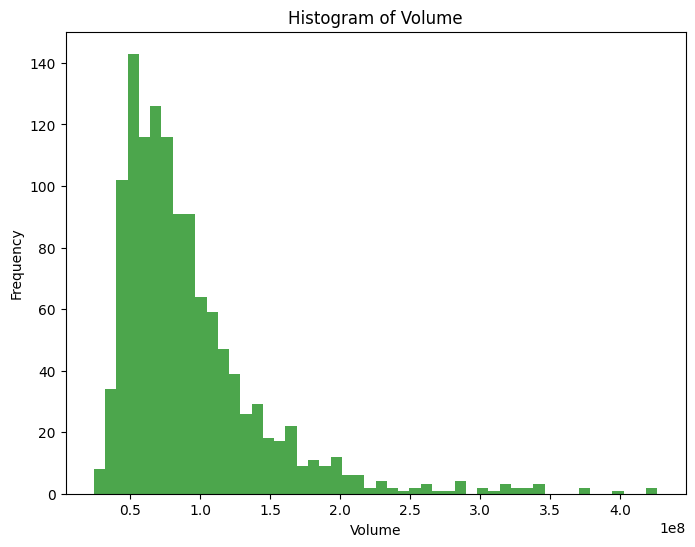

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['Volume'], bins=50, color='green', alpha=0.7)
plt.title('Histogram of Volume')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.show()

Volume traded distribution so you can estimate liquidity levels

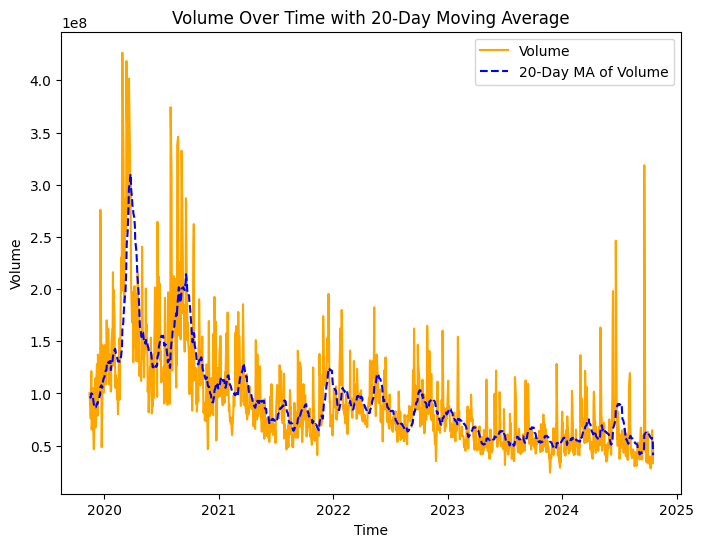

In [ ]:

plt.figure(figsize=(8, 6))
plt.plot(df['Volume'], color='orange', label='Volume')
plt.plot(df['volume_20dma'], color='blue', linestyle='--', label='20-Day MA of Volume')
plt.title('Volume Over Time with 20-Day Moving Average')
plt.xlabel('Time')
plt.ylabel('Volume')
plt.legend()
plt.show()

Volume levels over time, this can be further smoothed to better estimate the liquidity levels using 20-day moving average

In [ ]:
# Calculation of risk using predefined tolerance level (99th percentile)
level = 0.99
shares = 1000  # Assume we buy 1000 shares of AAPL

var = np.percentile(df['ret'].abs(), level * 100) * shares * df['Close'].tail(1).values[0]

# Calculate the VaR threshold for absolute returns
var_threshold = np.percentile(df['ret'].abs(), level * 100)

# Calculate Expected Shortfall (ES) in cash terms using absolute returns
es = df['ret'][df['ret'].abs() >= var_threshold].mean() * shares * df['Close'].tail(1).values[0]

print(f"99% VaR for AAPL (in cash): ${var:,.2f}")
print(f"99% Expected Shortfall for AAPL (in cash), assuming we passed the VAR: ${es:,.2f}")
print(f"total: $ {es+var:,.2f}")

99% VaR for AAPL (in cash): $16,724.69
99% Expected Shortfall for AAPL (in cash), assuming we passed the VAR: $7,733.37
total: $ 24,458.06


In [ ]:
G = nx.DiGraph()
G.add_node("Get Data (AAPL)")
G.add_node("Get Customer Purchase Power")
G.add_node("Calculate Volatility and Returns")
G.add_node("Visualize Risk (Diagrams)")
G.add_node("Calculate VaR & ES")
G.add_node("Communicate Results to Customer")

# Add edges to represent the flow
G.add_edges_from([
    ("Get Data (AAPL)", "Get Customer Purchase Power"),
    ("Get Customer Purchase Power", "Calculate Volatility and Returns"),
    ("Calculate Volatility and Returns", "Visualize Risk (Diagrams)"),
    ("Visualize Risk (Diagrams)", "Calculate VaR & ES"),
    ("Calculate VaR & ES", "Communicate Results to Customer")
])

Here we show the workflow using Directed Graphs


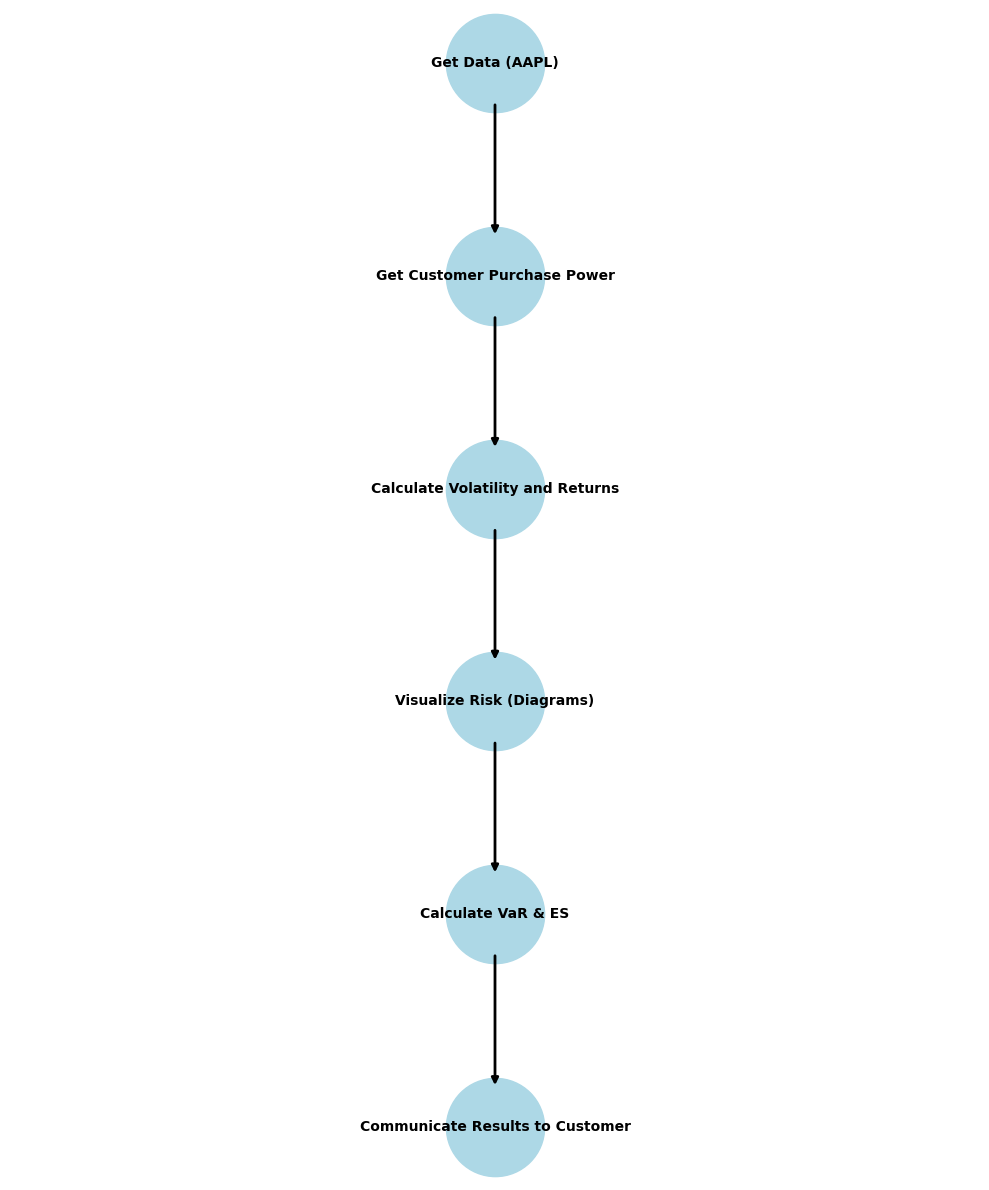

In [ ]:
pos = {
    "Get Data (AAPL)": (0, 5),
    "Get Customer Purchase Power": (0, 4),
    "Calculate Volatility and Returns": (0, 3),
    "Visualize Risk (Diagrams)": (0, 2),
    "Calculate VaR & ES": (0, 1),
    "Communicate Results to Customer": (0, 0)
}

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 12))

# Draw nodes with larger size
nx.draw_networkx_nodes(
    G, pos, node_color='lightblue', node_size=5000, ax=ax
)

# Draw labels
nx.draw_networkx_labels(
    G, pos, font_size=10, font_weight='bold', ax=ax, verticalalignment='center'
)

# Manually draw arrows
for edge in G.edges():
    start, end = edge
    ax.annotate(
        '',
        xy=pos[end],
        xytext=pos[start],
        arrowprops=dict(
            arrowstyle='-|>',
            color='black',
            lw=2,
            shrinkA=30,
            shrinkB=30,
        )
    )
ax.set_axis_off()
plt.tight_layout()
plt.show()